In [1]:
!pip install wordcloud matplotlib seaborn nltk pandas numpy

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords
from collections import Counter
import re
import json
import zipfile
import os
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')

print('All libraries loaded!')

All libraries loaded!


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/wagueacarinefongang/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/wagueacarinefongang/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
# Load Kaggle dataset
df = pd.read_csv('tweets.csv')
print('Kaggle dataset loaded!')
print(f'Total tweets: {len(df)}')
df.head()

Kaggle dataset loaded!
Total tweets: 11370


,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0


In [4]:
# Load Zenodo dataset
with zipfile.ZipFile('disaster-tweet-filtering-incident-tweets.zip', 'r') as zip_ref:
    zip_ref.extractall('zenodo_data')

all_zenodo_tweets = []
for root, dirs, files in os.walk('zenodo_data'):
    for file in files:
        if file.endswith('.ndjson'):
            filepath = os.path.join(root, file)
            with open(filepath, 'r') as f:
                for line in f:
                    tweet = json.loads(line.strip())
                    all_zenodo_tweets.append(tweet)

df_zenodo = pd.DataFrame(all_zenodo_tweets)
print(f'Zenodo dataset loaded!')
print(f'Total tweets: {len(df_zenodo)}')
df_zenodo.head()

Zenodo dataset loaded!
Total tweets: 163718


,id,text,relevance
0,406553907700449280,terrible here in glasgow helicopter crashed in...,1
1,406555220513394688,helicopter 'crashes into pub in glasgow' <URL>...,1
2,406555392492462080,breaking: a helicopter has crashed in to the r...,1
3,406555799344136193,labour mp jim murphy says a helicopter has cra...,1
4,406556302643822592,anybody heard anything about a helicopter cras...,1


In [5]:
# Cleaning text for BOTH datasets
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)      # remove URLs
    text = re.sub(r'@\w+', '', text)                 # remove mentions
    text = re.sub(r'#\w+', '', text)                 # remove full hashtags
    text = re.sub(r'\burl\b', '', text)              # remove url placeholder
    text = re.sub(r'\buser\b', '', text)             # remove user placeholder
    text = re.sub(r'\bnumber\b', '', text)           # remove number placeholder
    text = re.sub(r'\brepeat\b', '', text)           # remove repeat placeholder
    text = re.sub(r'\bhashtag\b', '', text)          # remove hashtag placeholder
    text = re.sub(r'\brt\b', '', text)               # remove retweet tag
    text = re.sub(r'\bvia\b', '', text)              # remove via
    text = re.sub(r'[^a-zA-Z\s]', '', text)          # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()         # remove extra spaces
    return text

# Apply to BOTH datasets
df['clean_text'] = df['text'].apply(clean_text)
df_zenodo['clean_text'] = df_zenodo['text'].apply(clean_text)

print('Both datasets cleaned!')
print('\nKaggle example:')
print('Original:', df['text'][0])
print('Cleaned:', df['clean_text'][0])
print('\nZenodo example:')
print('Original:', df_zenodo['text'][0])
print('Cleaned:', df_zenodo['clean_text'][0])

Both datasets cleaned!

Kaggle example:
Original: Communal violence in Bhainsa, Telangana. "Stones were pelted on Muslims' houses and some houses and vehicles were set ablaze…
Cleaned: communal violence in bhainsa telangana stones were pelted on muslims houses and some houses and vehicles were set ablaze

Zenodo example:
Original: terrible here in glasgow helicopter crashed into roof of pub
Cleaned: terrible here in glasgow helicopter crashed into roof of pub


In [18]:
# Basic overview of both datasets
print('=== KAGGLE DATASET INFO ===')
print(f'Total tweets: {len(df)}')
print(f'Columns: {list(df.columns)}')
print(f'\nMissing values:')
print(df.isnull().sum())

print('\n=== ZENODO DATASET INFO ===')
print(f'Total tweets: {len(df_zenodo)}')
print(f'Columns: {list(df_zenodo.columns)}')
print(f'\nMissing values:')
print(df_zenodo.isnull().sum())

=== KAGGLE DATASET INFO ===
Total tweets: 11370
Columns: ['id', 'keyword', 'location', 'text', 'target', 'clean_text', 'tweet_length']

Missing values:
id                 0
keyword            0
location        3418
text               0
target             0
clean_text         0
tweet_length       0
dtype: int64

=== ZENODO DATASET INFO ===
Total tweets: 163718
Columns: ['id', 'text', 'relevance', 'clean_text', 'tweet_length']

Missing values:
id              2760
text               0
relevance          0
clean_text         0
tweet_length       0
dtype: int64


In [6]:
# Basic overview of both datasets
print('=== KAGGLE DATASET INFO ===')
print(f'Total tweets: {len(df)}')
print(f'Columns: {list(df.columns)}')
print(f'\nMissing values:')
print(df.isnull().sum())

print('\n=== ZENODO DATASET INFO ===')
print(f'Total tweets: {len(df_zenodo)}')
print(f'Columns: {list(df_zenodo.columns)}')
print(f'\nMissing values:')
print(df_zenodo.isnull().sum())

=== KAGGLE DATASET INFO ===
Total tweets: 11370
Columns: ['id', 'keyword', 'location', 'text', 'target', 'clean_text']

Missing values:
id               0
keyword          0
location      3418
text             0
target           0
clean_text       0
dtype: int64

=== ZENODO DATASET INFO ===
Total tweets: 163718
Columns: ['id', 'text', 'relevance', 'clean_text']

Missing values:
id            2760
text             0
relevance        0
clean_text       0
dtype: int64


=== KAGGLE Label Distribution ===
Non-disaster tweets (0): 9256
Disaster tweets (1): 2114
Percentage disaster: 18.6%
Percentage non-disaster: 81.4%

=== ZENODO Label Distribution ===
Relevant (1): 81859
Not Relevant (0): 81859
Percentage relevant: 50.0%
Percentage not relevant: 50.0%


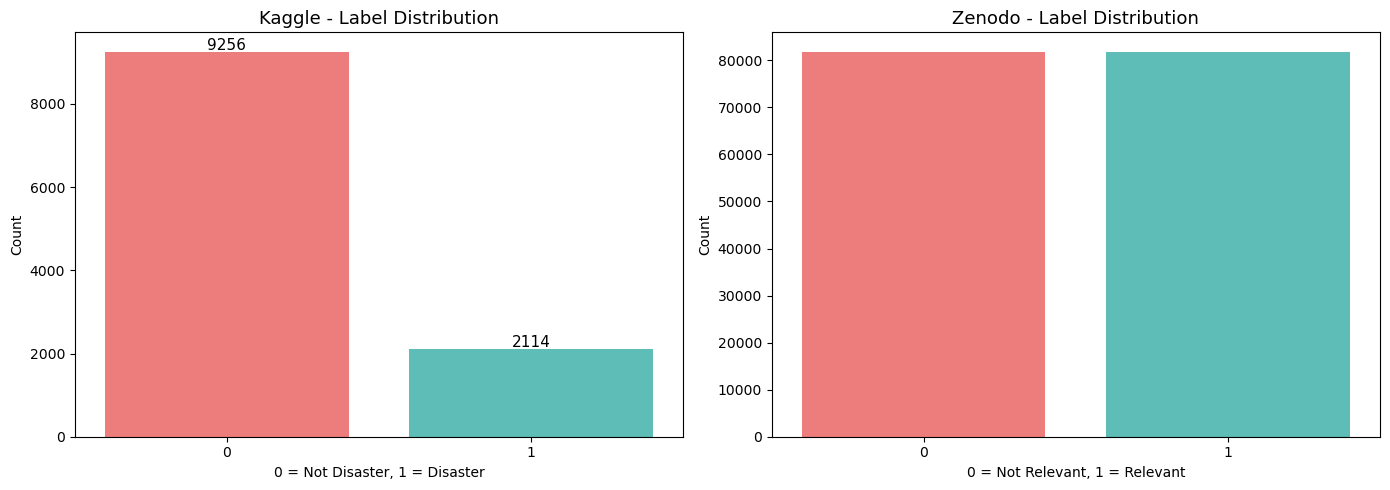

In [7]:
# Label distribution for both datasets
label_counts = df['target'].value_counts()
print('=== KAGGLE Label Distribution ===')
print(f'Non-disaster tweets (0): {label_counts[0]}')
print(f'Disaster tweets (1): {label_counts[1]}')
print(f'Percentage disaster: {label_counts[1]/len(df)*100:.1f}%')
print(f'Percentage non-disaster: {label_counts[0]/len(df)*100:.1f}%')

zenodo_counts = df_zenodo['relevance'].value_counts()
print('\n=== ZENODO Label Distribution ===')
print(f'Relevant (1): {zenodo_counts[1]}')
print(f'Not Relevant (0): {zenodo_counts[0]}')
print(f'Percentage relevant: {zenodo_counts[1]/len(df_zenodo)*100:.1f}%')
print(f'Percentage not relevant: {zenodo_counts[0]/len(df_zenodo)*100:.1f}%')

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='target', data=df, palette=['#FF6B6B', '#4ECDC4'], ax=axes[0])
axes[0].set_title('Kaggle - Label Distribution', fontsize=13)
axes[0].set_xlabel('0 = Not Disaster, 1 = Disaster')
axes[0].set_ylabel('Count')
for i, count in enumerate(label_counts):
    axes[0].text(i, count + 50, str(count), ha='center', fontsize=11)

sns.countplot(x='relevance', data=df_zenodo, palette=['#FF6B6B', '#4ECDC4'], ax=axes[1])
axes[1].set_title('Zenodo - Label Distribution', fontsize=13)
axes[1].set_xlabel('0 = Not Relevant, 1 = Relevant')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

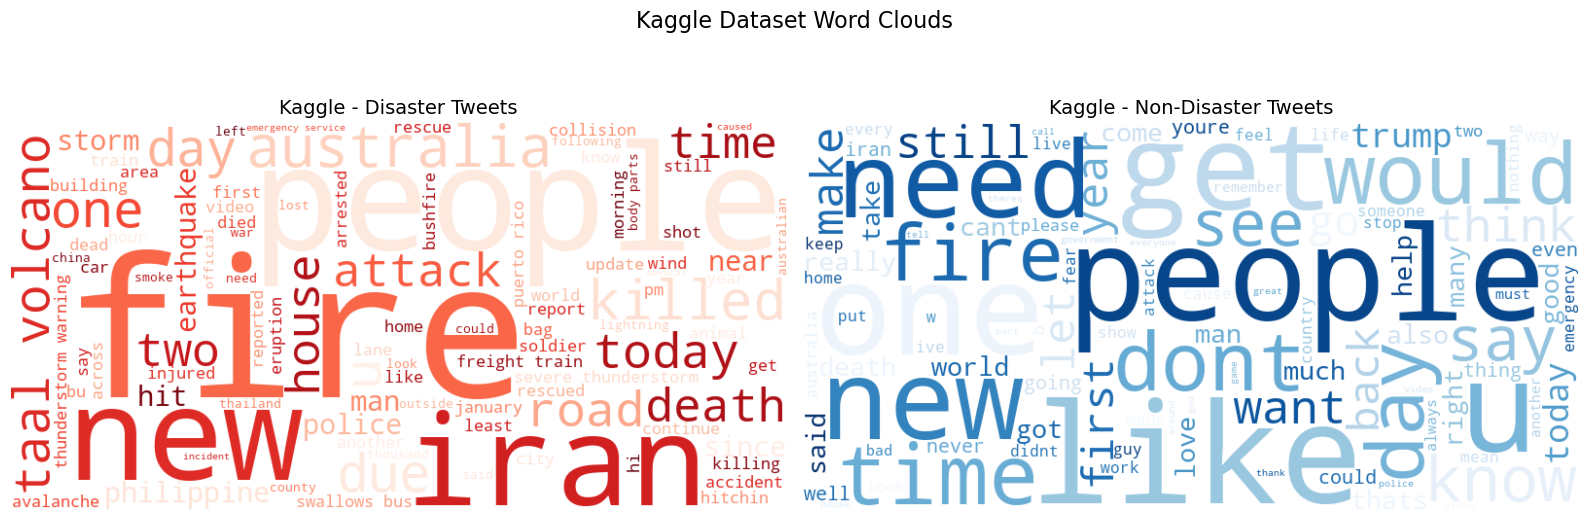

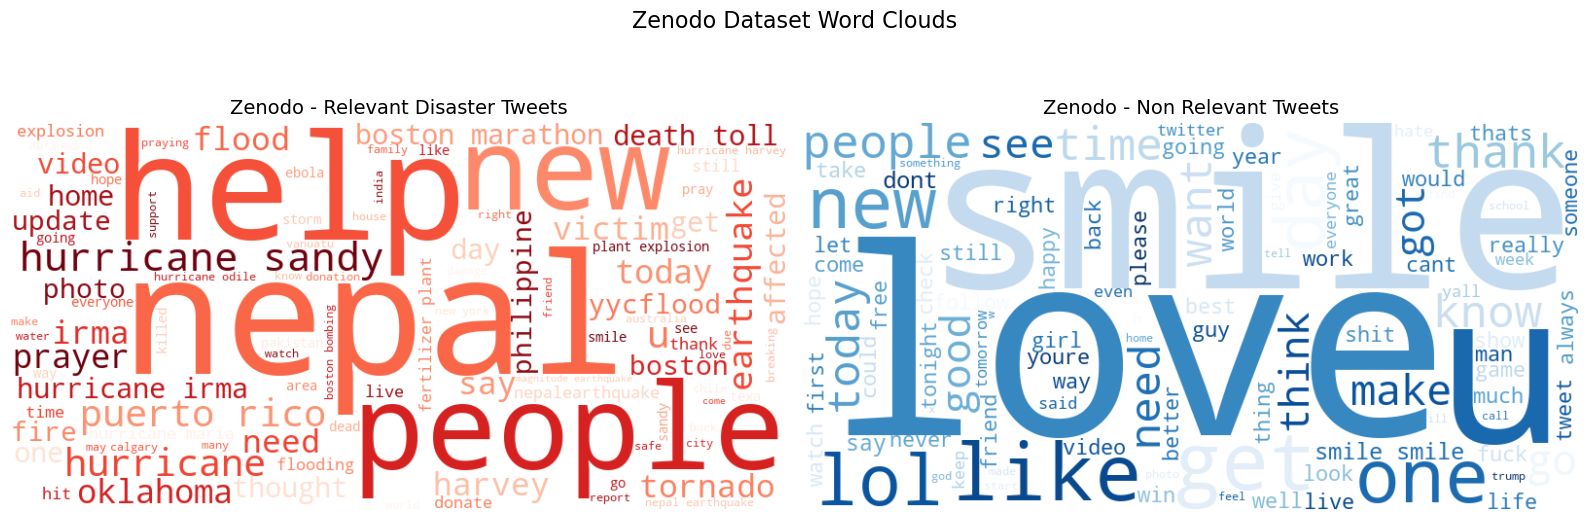

In [8]:
# Word clouds for both datasets
stop_words = set(stopwords.words('english'))
stop_words.update(['amp', 'th', 'im', 'url', 'hashtag', 'user', 'number', 'repeat', 'rt', 'via'])

# Kaggle word clouds
disaster_text = ' '.join(df[df['target'] == 1]['clean_text'])
non_disaster_text = ' '.join(df[df['target'] == 0]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
wc1 = WordCloud(width=800, height=400, background_color='white', colormap='Reds', stopwords=stop_words, max_words=100).generate(disaster_text)
axes[0].imshow(wc1, interpolation='bilinear')
axes[0].set_title('Kaggle - Disaster Tweets', fontsize=14)
axes[0].axis('off')

wc2 = WordCloud(width=800, height=400, background_color='white', colormap='Blues', stopwords=stop_words, max_words=100).generate(non_disaster_text)
axes[1].imshow(wc2, interpolation='bilinear')
axes[1].set_title('Kaggle - Non-Disaster Tweets', fontsize=14)
axes[1].axis('off')

plt.suptitle('Kaggle Dataset Word Clouds', fontsize=16)
plt.tight_layout()
plt.show()

# Zenodo word clouds
zenodo_relevant = ' '.join(df_zenodo[df_zenodo['relevance'] == 1]['clean_text'])
zenodo_not_relevant = ' '.join(df_zenodo[df_zenodo['relevance'] == 0]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
wc3 = WordCloud(width=800, height=400, background_color='white', colormap='Reds', stopwords=stop_words, max_words=100).generate(zenodo_relevant)
axes[0].imshow(wc3, interpolation='bilinear')
axes[0].set_title('Zenodo - Relevant Disaster Tweets', fontsize=14)
axes[0].axis('off')

wc4 = WordCloud(width=800, height=400, background_color='white', colormap='Blues', stopwords=stop_words, max_words=100).generate(zenodo_not_relevant)
axes[1].imshow(wc4, interpolation='bilinear')
axes[1].set_title('Zenodo - Non Relevant Tweets', fontsize=14)
axes[1].axis('off')

plt.suptitle('Zenodo Dataset Word Clouds', fontsize=16)
plt.tight_layout()
plt.show()

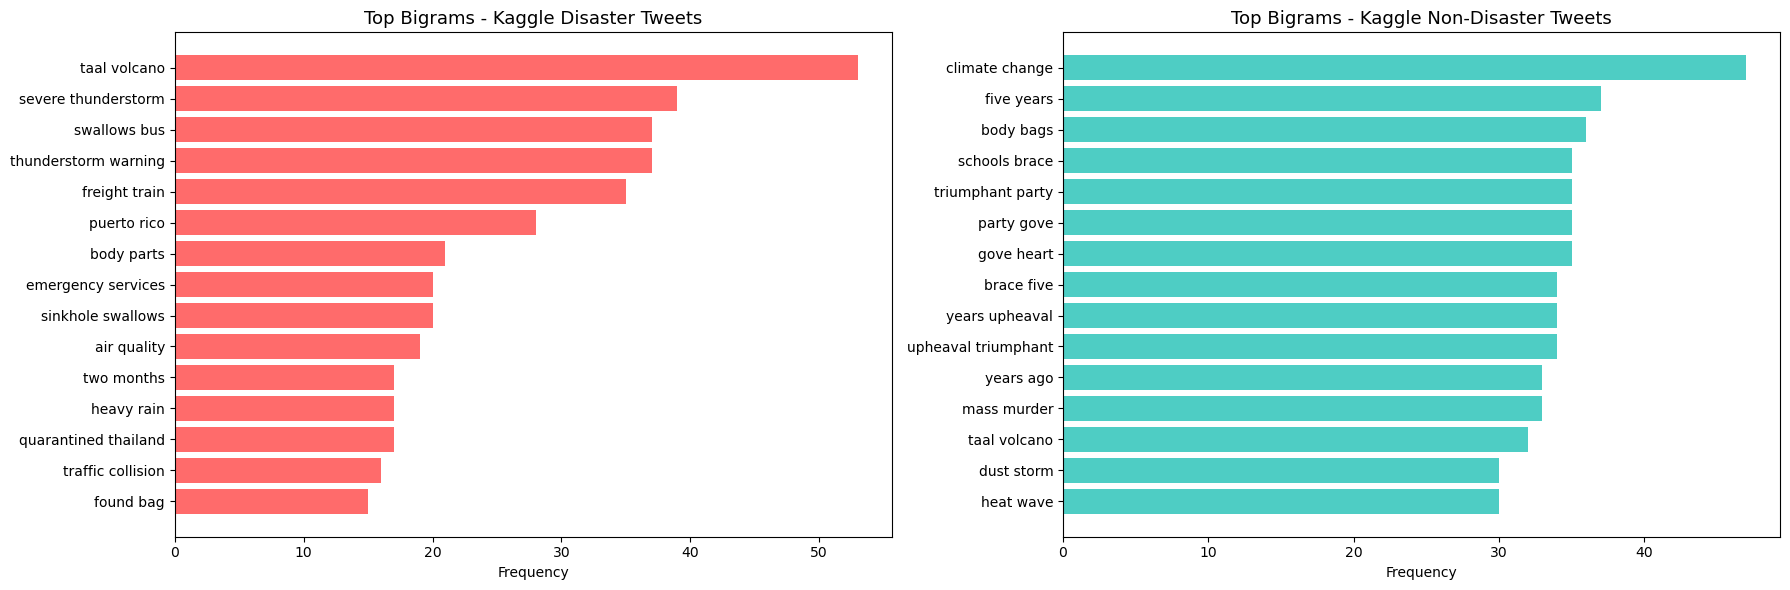

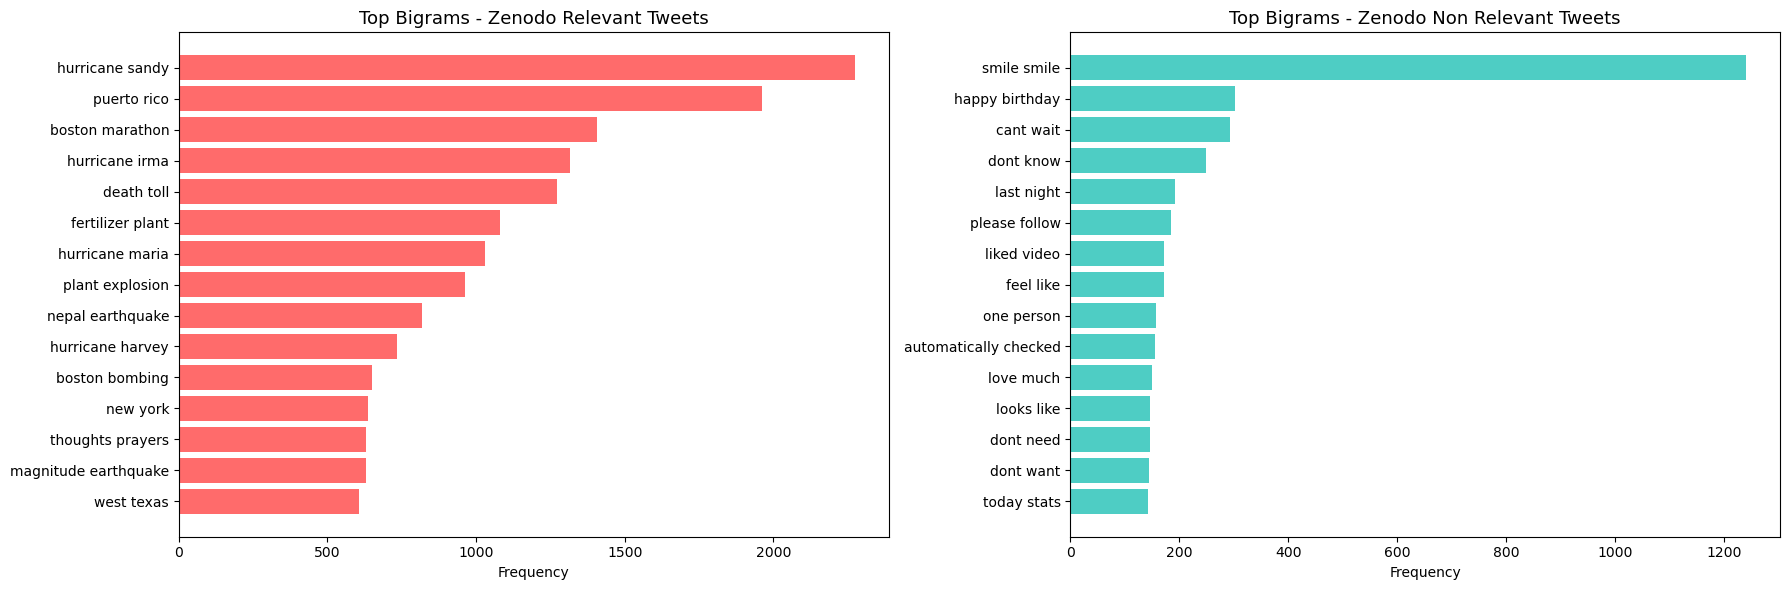

In [9]:
# N-gram analysis for both datasets
def get_top_ngrams(text, n, top_k=15):
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    n_grams = list(ngrams(words, n))
    return Counter(n_grams).most_common(top_k)

# Kaggle bigrams
disaster_bigrams = get_top_ngrams(disaster_text, 2)
non_disaster_bigrams = get_top_ngrams(non_disaster_text, 2)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
labels, counts = zip(*disaster_bigrams)
labels = [' '.join(l) for l in labels]
axes[0].barh(labels[::-1], counts[::-1], color='#FF6B6B')
axes[0].set_title('Top Bigrams - Kaggle Disaster Tweets', fontsize=13)
axes[0].set_xlabel('Frequency')

labels2, counts2 = zip(*non_disaster_bigrams)
labels2 = [' '.join(l) for l in labels2]
axes[1].barh(labels2[::-1], counts2[::-1], color='#4ECDC4')
axes[1].set_title('Top Bigrams - Kaggle Non-Disaster Tweets', fontsize=13)
axes[1].set_xlabel('Frequency')
plt.tight_layout()
plt.show()

# Zenodo bigrams
zenodo_bigrams_rel = get_top_ngrams(zenodo_relevant, 2)
zenodo_bigrams_nonrel = get_top_ngrams(zenodo_not_relevant, 2)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
labels3, counts3 = zip(*zenodo_bigrams_rel)
labels3 = [' '.join(l) for l in labels3]
axes[0].barh(labels3[::-1], counts3[::-1], color='#FF6B6B')
axes[0].set_title('Top Bigrams - Zenodo Relevant Tweets', fontsize=13)
axes[0].set_xlabel('Frequency')

labels4, counts4 = zip(*zenodo_bigrams_nonrel)
labels4 = [' '.join(l) for l in labels4]
axes[1].barh(labels4[::-1], counts4[::-1], color='#4ECDC4')
axes[1].set_title('Top Bigrams - Zenodo Non Relevant Tweets', fontsize=13)
axes[1].set_xlabel('Frequency')
plt.tight_layout()
plt.show()

=== KAGGLE Tweet Length Stats ===
Disaster tweets:
count    2114.000000
mean       17.355724
std         4.589154
min         1.000000
25%        14.000000
50%        18.000000
75%        21.000000
max        29.000000
Name: tweet_length, dtype: float64

Non-disaster tweets:
count    9256.000000
mean       17.122839
std         5.699776
min         1.000000
25%        14.000000
50%        18.000000
75%        21.000000
max        32.000000
Name: tweet_length, dtype: float64


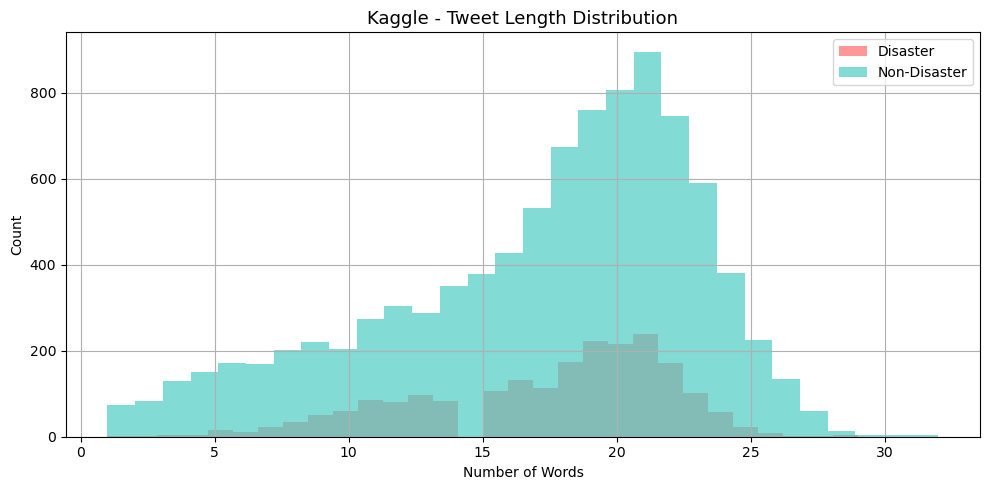

In [12]:
# Kaggle tweet length analysis
df['tweet_length'] = df['text'].apply(lambda x: len(str(x).split()))

print('=== KAGGLE Tweet Length Stats ===')
print('Disaster tweets:')
print(df[df['target']==1]['tweet_length'].describe())
print('\nNon-disaster tweets:')
print(df[df['target']==0]['tweet_length'].describe())

plt.figure(figsize=(10, 5))
df[df['target']==1]['tweet_length'].hist(bins=30, alpha=0.7, color='#FF6B6B', label='Disaster')
df[df['target']==0]['tweet_length'].hist(bins=30, alpha=0.7, color='#4ECDC4', label='Non-Disaster')
plt.title('Kaggle - Tweet Length Distribution', fontsize=13)
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

=== ZENODO Tweet Length Stats ===
Relevant tweets:
count    81859.000000
mean        16.623878
std          5.634689
min          1.000000
25%         13.000000
50%         17.000000
75%         21.000000
max        429.000000
Name: tweet_length, dtype: float64

Non-relevant tweets:
count    81859.000000
mean        13.622338
std          7.221544
min          1.000000
25%          8.000000
50%         13.000000
75%         19.000000
max         83.000000
Name: tweet_length, dtype: float64


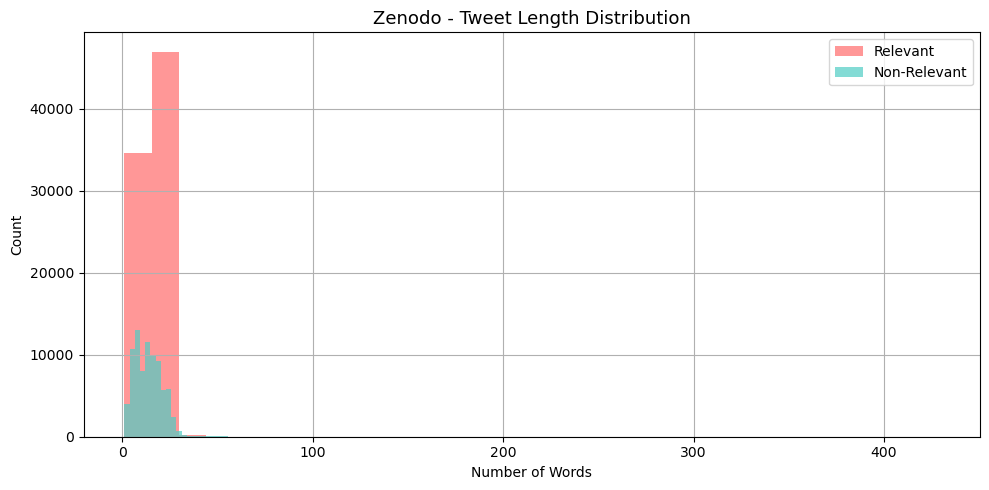

In [14]:
# Zenodo tweet length analysis
df_zenodo['tweet_length'] = df_zenodo['text'].apply(lambda x: len(str(x).split()))

print('=== ZENODO Tweet Length Stats ===')
print('Relevant tweets:')
print(df_zenodo[df_zenodo['relevance']==1]['tweet_length'].describe())
print('\nNon-relevant tweets:')
print(df_zenodo[df_zenodo['relevance']==0]['tweet_length'].describe())

plt.figure(figsize=(10, 5))
df_zenodo[df_zenodo['relevance']==1]['tweet_length'].hist(bins=30, alpha=0.7, color='#FF6B6B', label='Relevant')
df_zenodo[df_zenodo['relevance']==0]['tweet_length'].hist(bins=30, alpha=0.7, color='#4ECDC4', label='Non-Relevant')
plt.title('Zenodo - Tweet Length Distribution', fontsize=13)
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Combine datasets & save
df_kaggle_clean = df[['clean_text', 'target']].rename(columns={'clean_text': 'text'})
df_zenodo_clean = df_zenodo[['clean_text', 'relevance']].rename(columns={'clean_text': 'text', 'relevance': 'target'})

df_combined = pd.concat([df_kaggle_clean, df_zenodo_clean], ignore_index=True)

print('=== COMBINED DATASET ===')
print(f'Kaggle tweets: {len(df_kaggle_clean)}')
print(f'Zenodo tweets: {len(df_zenodo_clean)}')
print(f'Total combined: {len(df_combined)}')
print(f'\nCombined label distribution:')
print(df_combined['target'].value_counts())
print(f'\nDisaster %: {df_combined["target"].value_counts()[1]/len(df_combined)*100:.1f}%')
print(f'Non-disaster %: {df_combined["target"].value_counts()[0]/len(df_combined)*100:.1f}%')

df_combined.to_csv('combined_tweets.csv', index=False)
print('\nClean combined dataset saved!')

=== COMBINED DATASET ===
Kaggle tweets: 11370
Zenodo tweets: 163718
Total combined: 175088

Combined label distribution:
target
0    91115
1    83973
Name: count, dtype: int64

Disaster %: 48.0%
Non-disaster %: 52.0%

Clean combined dataset saved!


In [19]:
# Final Summary
print('=== FINAL DATA EXPLORATION SUMMARY ===')
print('\n--- KAGGLE DATASET ---')
print(f'Total tweets: {len(df)}')
print(f'Disaster tweets: {len(df[df["target"]==1])} (18.6%)')
print(f'Non-disaster tweets: {len(df[df["target"]==0])} (81.4%)')
print(f'Missing location data: {df["location"].isnull().sum()} (30%)')
print(f'Avg tweet length (disaster): {df[df["target"]==1]["tweet_length"].mean():.1f} words')
print(f'Avg tweet length (non-disaster): {df[df["target"]==0]["tweet_length"].mean():.1f} words')

print('\n--- ZENODO DATASET ---')
print(f'Total tweets: {len(df_zenodo)}')
print(f'Relevant tweets: {len(df_zenodo[df_zenodo["relevance"]==1])} (50%)')
print(f'Non-relevant tweets: {len(df_zenodo[df_zenodo["relevance"]==0])} (50%)')
print(f'Disasters covered: 48 across 10 disaster types')
print(f'Avg tweet length (relevant): {df_zenodo[df_zenodo["relevance"]==1]["tweet_length"].mean():.1f} words')
print(f'Avg tweet length (non-relevant): {df_zenodo[df_zenodo["relevance"]==0]["tweet_length"].mean():.1f} words')

print('\n--- COMBINED DATASET ---')
print(f'Total tweets: {len(df_combined)}')
print(f'Disaster tweets: {df_combined["target"].value_counts()[1]} (48%)')
print(f'Non-disaster tweets: {df_combined["target"].value_counts()[0]} (52%)')
print('\nKey Findings:')
print('1. Kaggle was heavily imbalanced - fixed by combining with Zenodo')
print('2. Words like fire and taal volcano appear in both categories - ambiguity challenge')
print('3. Tweet length is not a reliable predictor in Kaggle but slightly useful in Zenodo')
print('4. Zenodo shows much clearer separation between disaster and non-disaster language')
print('5. Combined dataset is 15x larger and nearly balanced - much better for modeling!')

=== FINAL DATA EXPLORATION SUMMARY ===

--- KAGGLE DATASET ---
Total tweets: 11370
Disaster tweets: 2114 (18.6%)
Non-disaster tweets: 9256 (81.4%)
Missing location data: 3418 (30%)
Avg tweet length (disaster): 17.4 words
Avg tweet length (non-disaster): 17.1 words

--- ZENODO DATASET ---
Total tweets: 163718
Relevant tweets: 81859 (50%)
Non-relevant tweets: 81859 (50%)
Disasters covered: 48 across 10 disaster types
Avg tweet length (relevant): 16.6 words
Avg tweet length (non-relevant): 13.6 words

--- COMBINED DATASET ---
Total tweets: 175088
Disaster tweets: 83973 (48%)
Non-disaster tweets: 91115 (52%)

Key Findings:
1. Kaggle was heavily imbalanced - fixed by combining with Zenodo
2. Words like fire and taal volcano appear in both categories - ambiguity challenge
3. Tweet length is not a reliable predictor in Kaggle but slightly useful in Zenodo
4. Zenodo shows much clearer separation between disaster and non-disaster language
5. Combined dataset is 15x larger and nearly balanced - 